# Credit Card Fraud Detection — ML Classification Project
**Steps:** Baseline Models → Class Balancing → PSO Optimization → Final Analysis

Run the cells **in order, top to bottom**. Each part builds on the previous one.


## 0. Setup — install libraries

In [1]:
!pip install imbalanced-learn pyswarms -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.3 MB/s eta 0:00:00


## 0.1 Upload the dataset
Run this cell and choose **`creditcard_sample5000.csv`** when the upload button appears.

In [2]:
from google.colab import files
uploaded = files.upload()   # choose creditcard_sample5000.csv when prompted

Saving creditcard_sample5000.csv to creditcard_sample5000.csv


## 0.2 Imports and shared helper functions

In [3]:
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import pyswarms as ps

RANDOM_STATE = 42
os.makedirs("results/confusion_matrices", exist_ok=True)
os.makedirs("results/roc_curves", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)

all_results = []  # every evaluate_model() call appends a row here


def evaluate_model(model, X_test, y_test, model_name, stage_tag, save_plots=True):
    """Evaluates an already-trained model, saves confusion matrix + ROC curve,
    prints metrics, and logs a row into all_results."""
    t0 = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - t0

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    auc = None
    if y_proba is not None and len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    if save_plots:
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - {model_name} ({stage_tag})")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.tight_layout()
        plt.savefig(f"results/confusion_matrices/{stage_tag}_{model_name}.png", dpi=150)
        plt.show()

    if save_plots and y_proba is not None and len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name} ({stage_tag})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"results/roc_curves/{stage_tag}_{model_name}.png", dpi=150)
        plt.show()

    row = {
        "stage": stage_tag, "model": model_name,
        "accuracy": acc, "precision_weighted": prec, "recall_weighted": rec,
        "f1_weighted": f1, "roc_auc": auc, "predict_time_sec": predict_time,
    }
    for cls_label in ["0", "1"]:
        if cls_label in report:
            row[f"precision_class{cls_label}"] = report[cls_label]["precision"]
            row[f"recall_class{cls_label}"] = report[cls_label]["recall"]
            row[f"f1_class{cls_label}"] = report[cls_label]["f1-score"]

    all_results.append(row)
    print(f"{model_name} [{stage_tag}] -> Accuracy={acc:.4f}  F1={f1:.4f}  AUC={auc}")
    return row


def time_fit(model, X_train, y_train):
    t0 = time.time()
    model.fit(X_train, y_train)
    return model, time.time() - t0


## Part 1 — Data Loading, Cleaning & Train-Validation-Test Split (80-10-10)
As instructed, the data is split into three parts:
- **80% Train** — used to fit the models
- **10% Validation** — used ONLY during PSO tuning (Part 4) to score candidate hyperparameters
- **10% Test** — held out completely, used only for final evaluation. Never balanced, never used to pick hyperparameters.

In [4]:
df = pd.read_csv("creditcard_sample5000.csv")
print("Raw shape:", df.shape)
print(df["Class"].value_counts())

df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

X = df.drop(columns=["Class"])
y = df["Class"]

scaler = StandardScaler()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

# Step 1: 80% train, 20% temp (stratified so fraud ratio stays the same in every split)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Step 2: split the remaining 20% into 10% validation + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print("\nTrain shape     :", X_train.shape, " Fraud ratio:", y_train.mean())
print("Validation shape:", X_val.shape, " Fraud ratio:", y_val.mean())
print("Test shape      :", X_test.shape, " Fraud ratio:", y_test.mean())

Raw shape: (5000, 31)
Class
0    4508
1     492
Name: count, dtype: int64
Shape after dropping duplicates: (4981, 31)

Train shape     : (3984, 30)  Fraud ratio: 0.09487951807228916
Validation shape: (498, 30)  Fraud ratio: 0.09437751004016064
Test shape      : (499, 30)  Fraud ratio: 0.09619238476953908


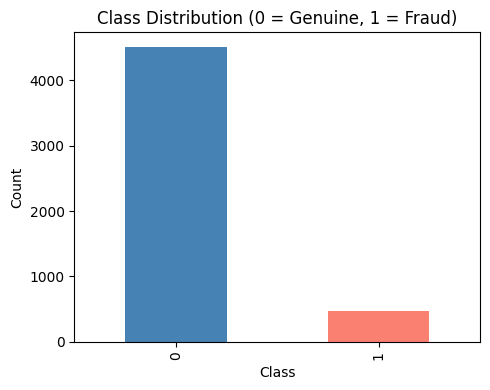

In [5]:
# Class distribution plot
plt.figure(figsize=(5,4))
y.value_counts().plot(kind="bar", color=["steelblue","salmon"])
plt.title("Class Distribution (0 = Genuine, 1 = Fraud)")
plt.xlabel("Class"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/tables/class_distribution.png", dpi=150)
plt.show()

## Part 2 — Baseline Machine Learning Models
Train several classifiers on the original (imbalanced) training data.


--- Training LogisticRegression ---
Training time: 0.045 sec


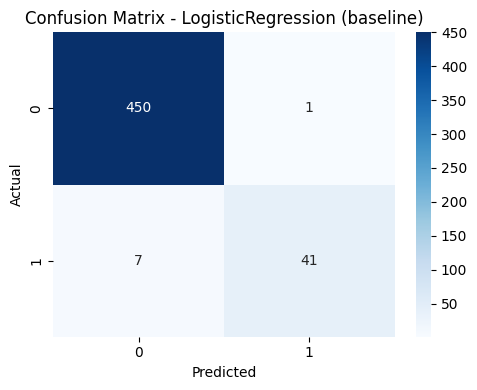

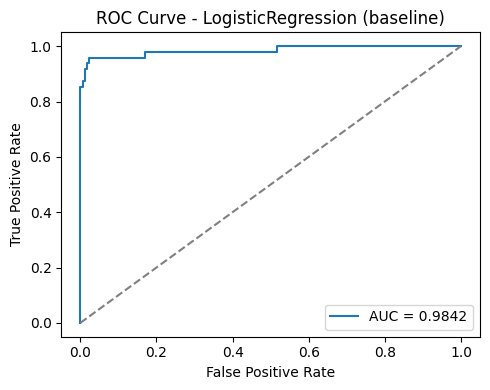

LogisticRegression [baseline] -> Accuracy=0.9840  F1=0.9835  AUC=0.9842479674796747

--- Training DecisionTree ---
Training time: 0.275 sec


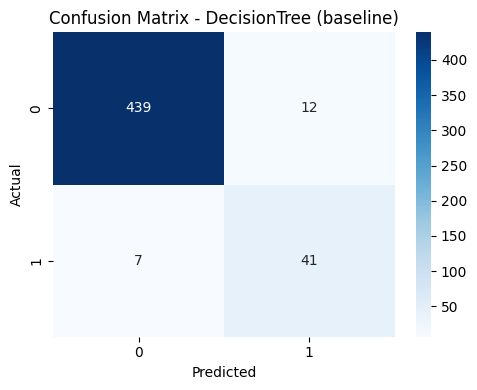

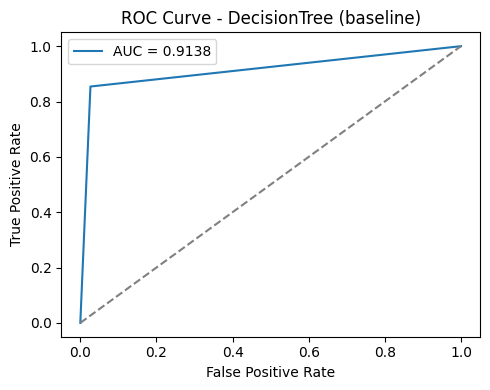

DecisionTree [baseline] -> Accuracy=0.9619  F1=0.9628  AUC=0.9137795639320029

--- Training RandomForest ---
Training time: 3.614 sec


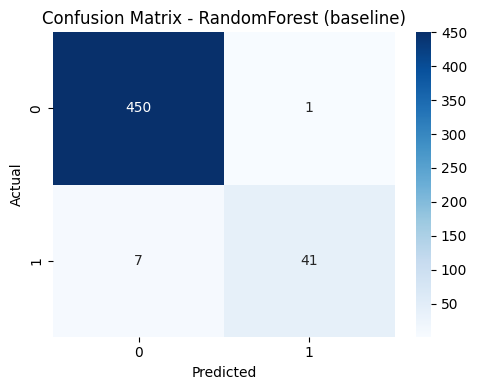

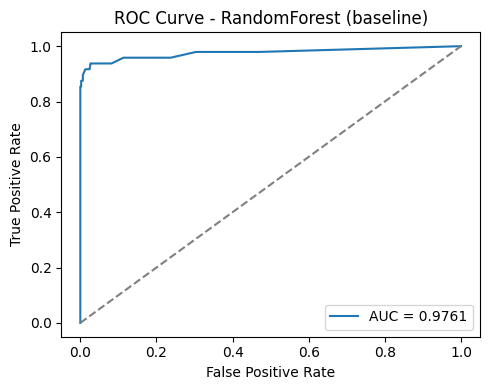

RandomForest [baseline] -> Accuracy=0.9840  F1=0.9835  AUC=0.9760947893569843

--- Training KNN ---
Training time: 0.004 sec


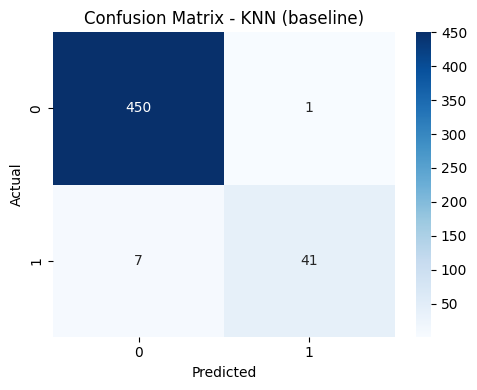

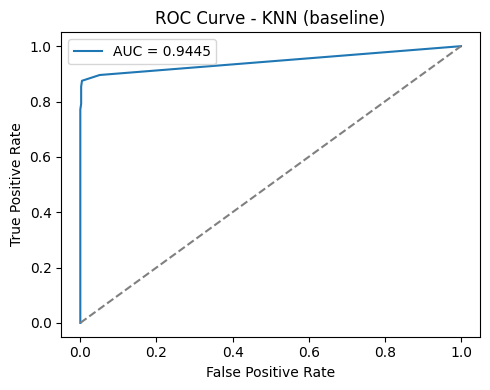

KNN [baseline] -> Accuracy=0.9840  F1=0.9835  AUC=0.9444521433850703

--- Training SVM ---
Training time: 0.689 sec


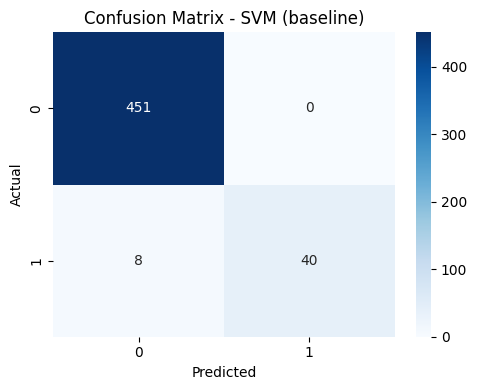

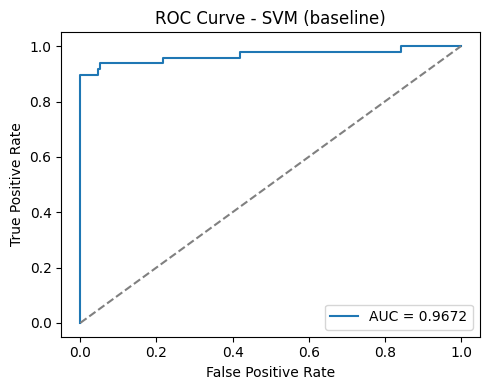

SVM [baseline] -> Accuracy=0.9840  F1=0.9833  AUC=0.9671563192904655

--- Training NaiveBayes ---
Training time: 0.006 sec


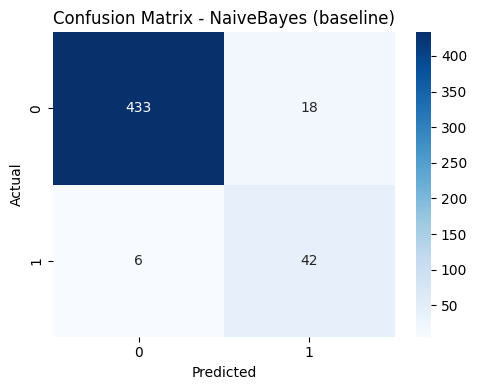

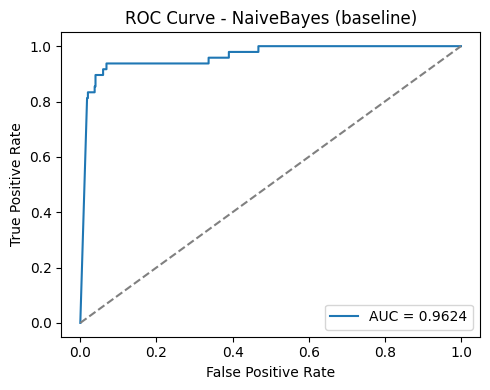

NaiveBayes [baseline] -> Accuracy=0.9519  F1=0.9543  AUC=0.9623521803399853


In [6]:
baseline_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "NaiveBayes": GaussianNB(),
}

trained_baseline = {}
baseline_train_times = {}

for name, model in baseline_models.items():
    print(f"\n--- Training {name} ---")
    fitted, t = time_fit(model, X_train, y_train)
    baseline_train_times[name] = t
    print(f"Training time: {t:.3f} sec")
    evaluate_model(fitted, X_test, y_test, model_name=name, stage_tag="baseline")
    trained_baseline[name] = fitted

### Baseline results table

In [7]:
baseline_df = pd.DataFrame([r for r in all_results if r["stage"]=="baseline"])
baseline_df

,stage,model,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc,predict_time_sec,precision_class0,recall_class0,f1_class0,precision_class1,recall_class1,f1_class1
0,baseline,LogisticRegression,0.983968,0.983866,0.983968,0.983487,0.984248,0.002165,0.984683,0.997783,0.991189,0.976190,0.854167,0.911111
1,baseline,DecisionTree,0.961924,0.964035,0.961924,0.962760,0.913780,0.002792,0.984305,0.973392,0.978818,0.773585,0.854167,0.811881
2,baseline,RandomForest,0.983968,0.983866,0.983968,0.983487,0.976095,0.037498,0.984683,0.997783,0.991189,0.976190,0.854167,0.911111
3,baseline,KNN,0.983968,0.983866,0.983968,0.983487,0.944452,0.026985,0.984683,0.997783,0.991189,0.976190,0.854167,0.911111
4,baseline,SVM,0.983968,0.984247,0.983968,0.983310,0.967156,0.016233,0.982571,1.000000,0.991209,1.000000,0.833333,0.909091
5,baseline,NaiveBayes,0.951904,0.958790,0.951904,0.954252,0.962352,0.002312,0.986333,0.960089,0.973034,0.700000,0.875000,0.777778


## Part 3 — Class Balancing (SMOTE, SMOTE-Tomek, ADASYN)
Balancing is applied to the TRAINING data only — the test set stays untouched
so the comparison remains realistic.

In [8]:
print("Original training class distribution:")
print(y_train.value_counts())

balancers = {
    "smote": SMOTE(random_state=RANDOM_STATE),
    "smote_tomek": SMOTETomek(random_state=RANDOM_STATE),
    "adasyn": ADASYN(random_state=RANDOM_STATE),
}

balanced_data = {}
for bname, balancer in balancers.items():
    X_bal, y_bal = balancer.fit_resample(X_train, y_train)
    balanced_data[bname] = (X_bal, y_bal)
    print(f"\n{bname} balanced distribution:")
    print(y_bal.value_counts())

Original training class distribution:
Class
0    3606
1     378
Name: count, dtype: int64

smote balanced distribution:
Class
0    3606
1    3606
Name: count, dtype: int64

smote_tomek balanced distribution:
Class
0    3604
1    3604
Name: count, dtype: int64

adasyn balanced distribution:
Class
1    3612
0    3606
Name: count, dtype: int64



========== Balancing technique: smote ==========

Training LogisticRegression on smote-balanced data ...
Training time: 0.054 sec


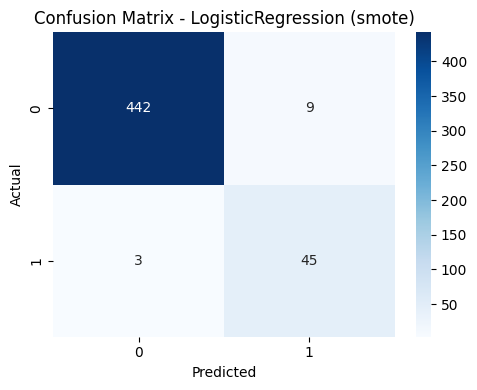

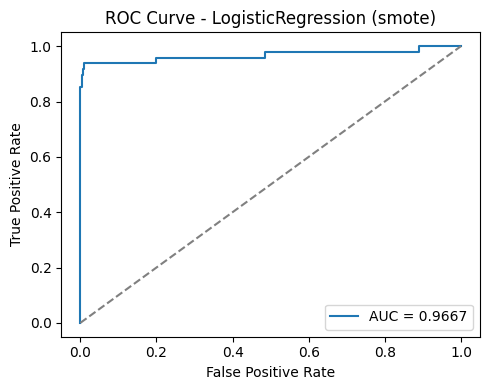

LogisticRegression [smote] -> Accuracy=0.9760  F1=0.9766  AUC=0.9666943828529194

Training DecisionTree on smote-balanced data ...
Training time: 0.399 sec


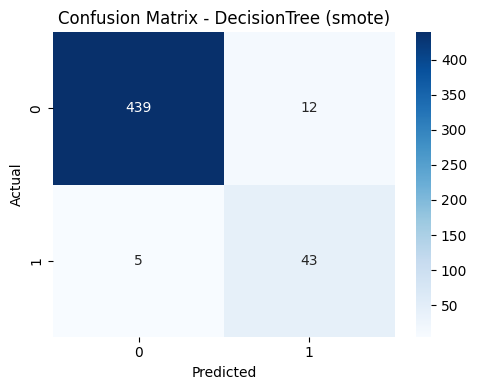

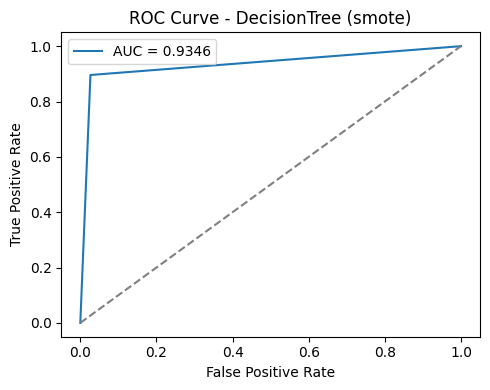

DecisionTree [smote] -> Accuracy=0.9659  F1=0.9670  AUC=0.9346128972653364

Training RandomForest on smote-balanced data ...
Training time: 3.018 sec


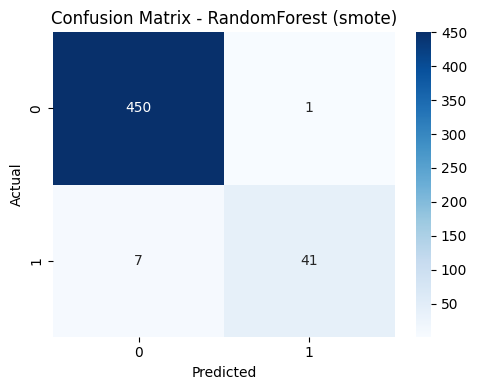

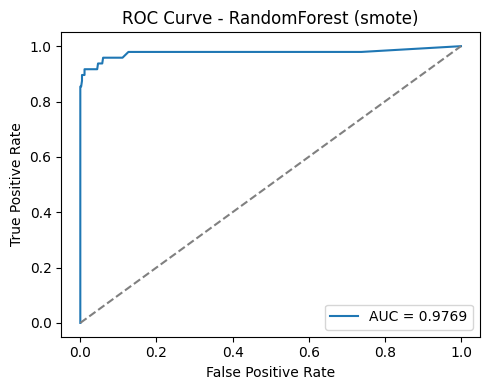

RandomForest [smote] -> Accuracy=0.9840  F1=0.9835  AUC=0.9768569844789357

Training KNN on smote-balanced data ...
Training time: 0.011 sec


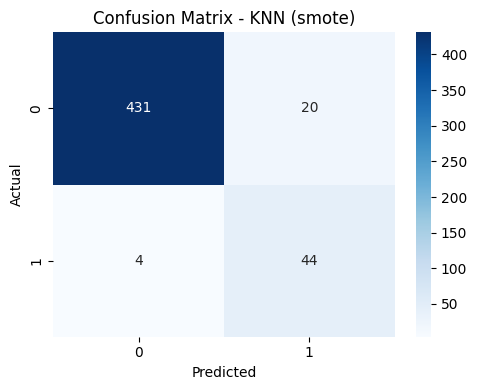

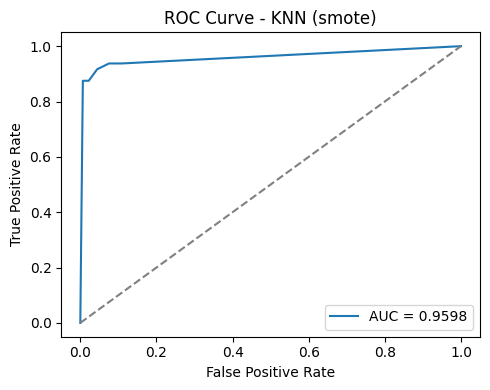

KNN [smote] -> Accuracy=0.9519  F1=0.9549  AUC=0.9598115299334812

Training SVM on smote-balanced data ...
Training time: 9.891 sec


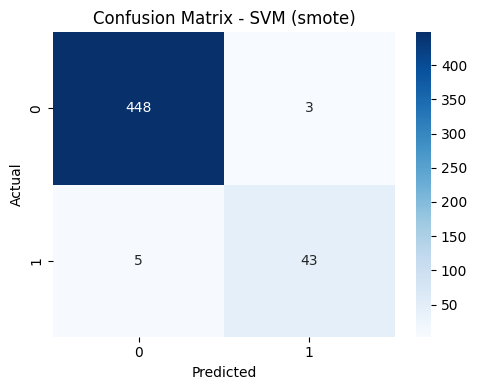

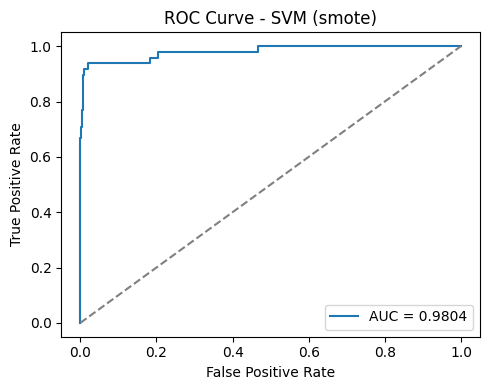

SVM [smote] -> Accuracy=0.9840  F1=0.9838  AUC=0.9804138950480414

Training NaiveBayes on smote-balanced data ...
Training time: 0.028 sec


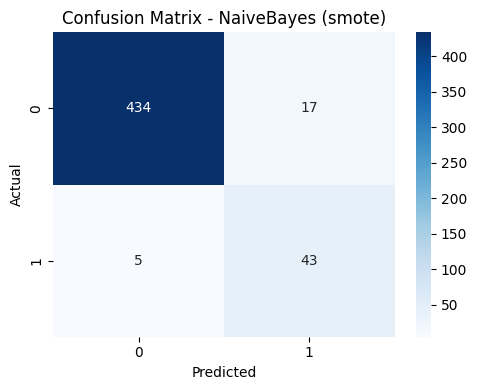

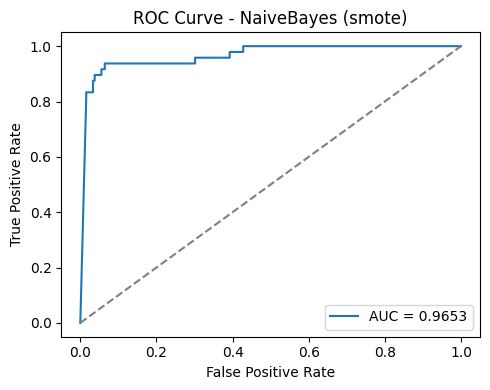

NaiveBayes [smote] -> Accuracy=0.9559  F1=0.9581  AUC=0.9653316703621582

========== Balancing technique: smote_tomek ==========

Training LogisticRegression on smote_tomek-balanced data ...
Training time: 0.283 sec


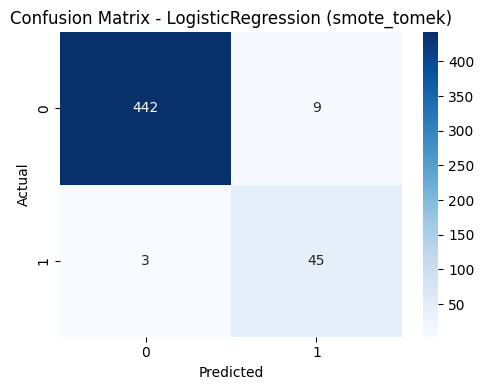

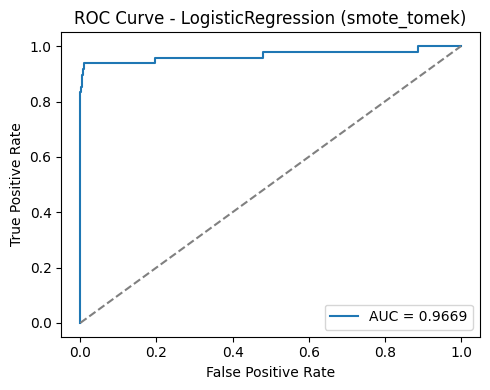

LogisticRegression [smote_tomek] -> Accuracy=0.9760  F1=0.9766  AUC=0.966879157427938

Training DecisionTree on smote_tomek-balanced data ...
Training time: 0.821 sec


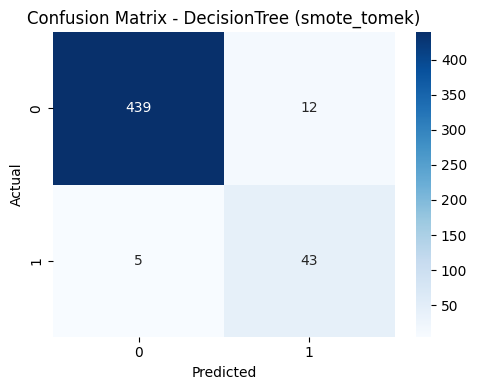

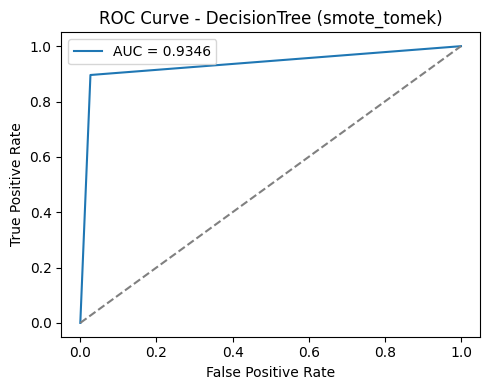

DecisionTree [smote_tomek] -> Accuracy=0.9659  F1=0.9670  AUC=0.9346128972653364

Training RandomForest on smote_tomek-balanced data ...
Training time: 5.441 sec


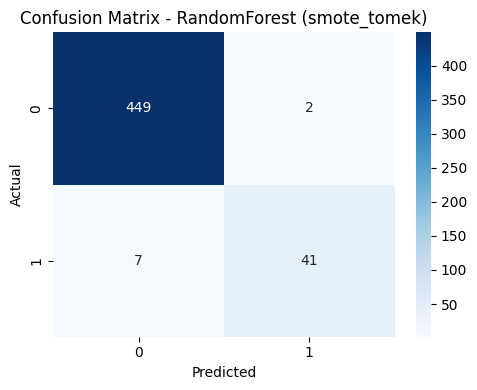

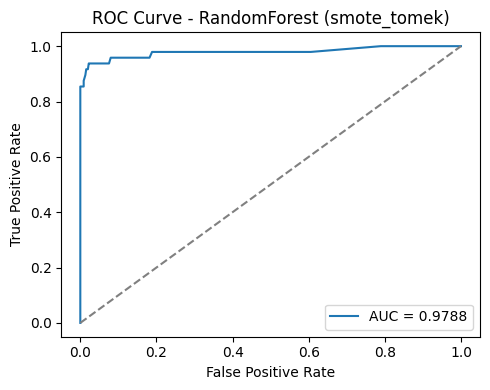

RandomForest [smote_tomek] -> Accuracy=0.9820  F1=0.9815  AUC=0.9788433111603843

Training KNN on smote_tomek-balanced data ...
Training time: 0.006 sec


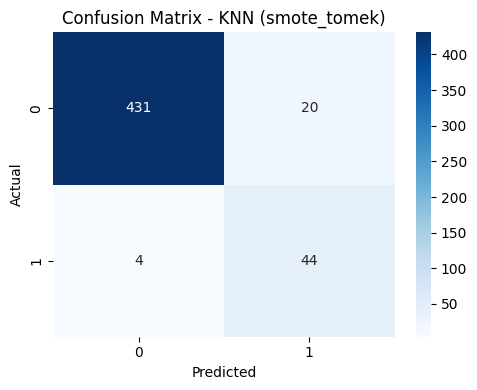

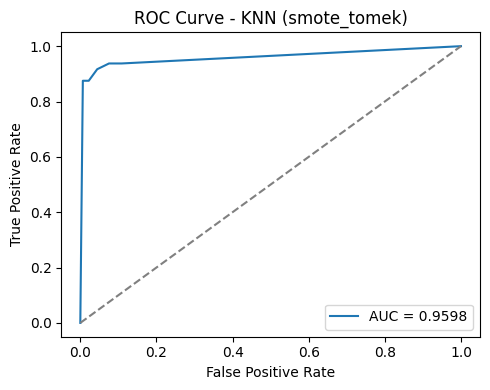

KNN [smote_tomek] -> Accuracy=0.9519  F1=0.9549  AUC=0.9598115299334812

Training SVM on smote_tomek-balanced data ...
Training time: 4.714 sec


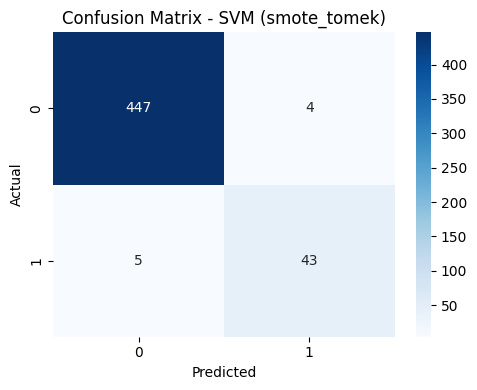

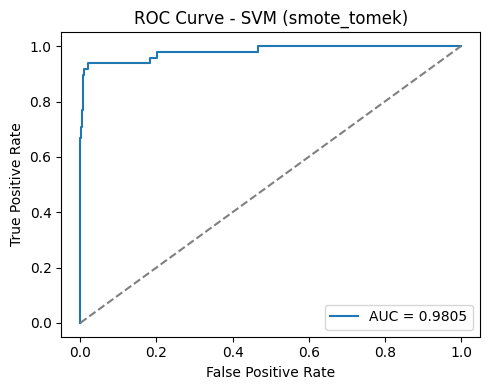

SVM [smote_tomek] -> Accuracy=0.9820  F1=0.9819  AUC=0.980460088691796

Training NaiveBayes on smote_tomek-balanced data ...
Training time: 0.009 sec


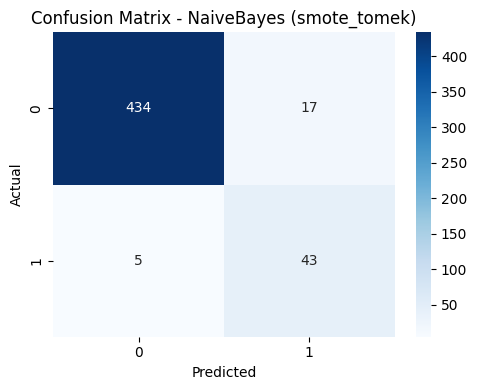

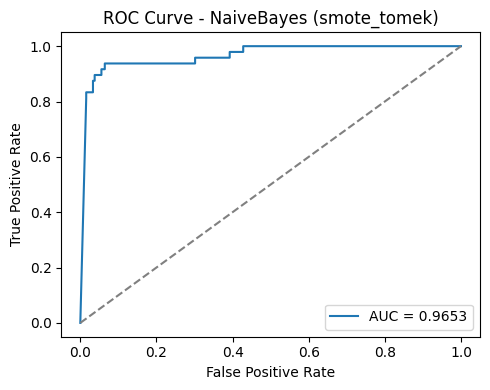

NaiveBayes [smote_tomek] -> Accuracy=0.9559  F1=0.9581  AUC=0.9653316703621582

========== Balancing technique: adasyn ==========

Training LogisticRegression on adasyn-balanced data ...
Training time: 0.060 sec


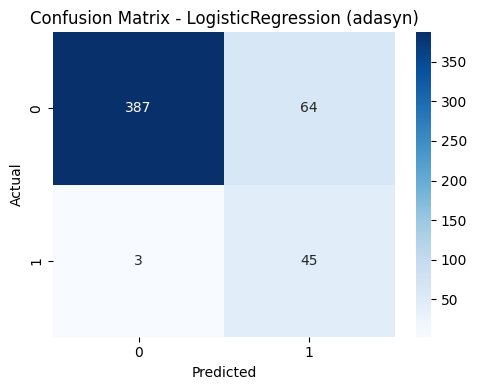

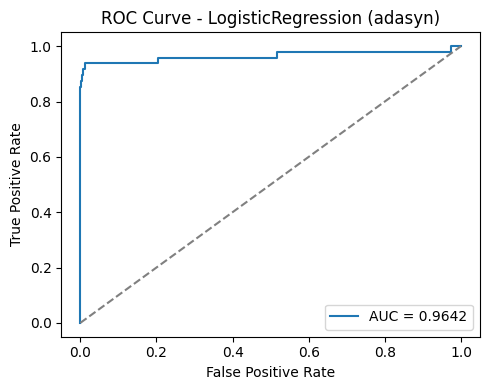

LogisticRegression [adasyn] -> Accuracy=0.8657  F1=0.8869  AUC=0.96419992609017

Training DecisionTree on adasyn-balanced data ...
Training time: 0.555 sec


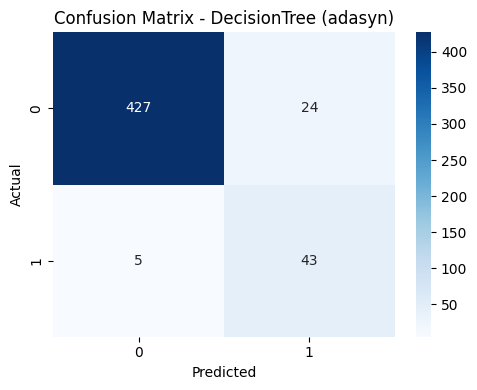

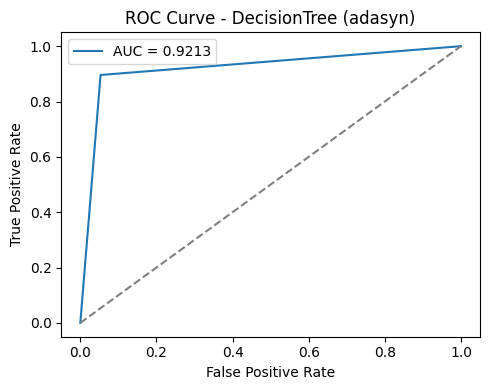

DecisionTree [adasyn] -> Accuracy=0.9419  F1=0.9461  AUC=0.921309127864006

Training RandomForest on adasyn-balanced data ...
Training time: 3.524 sec


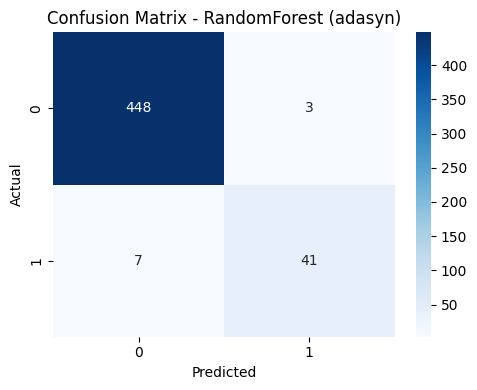

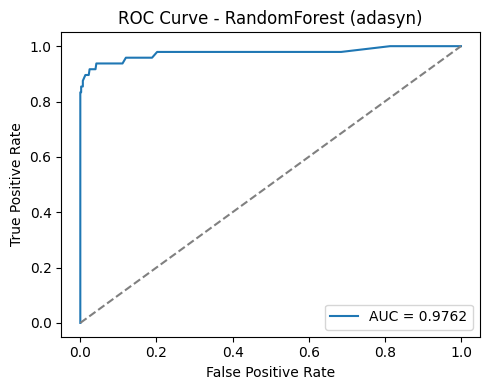

RandomForest [adasyn] -> Accuracy=0.9800  F1=0.9796  AUC=0.9761871766444936

Training KNN on adasyn-balanced data ...
Training time: 0.006 sec


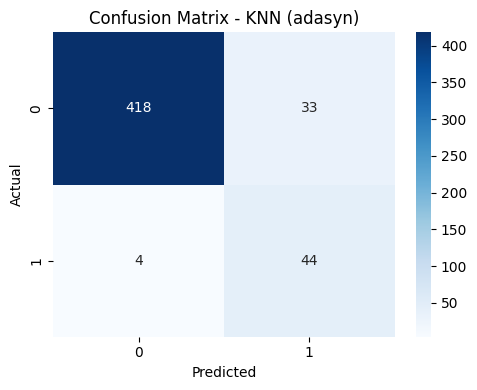

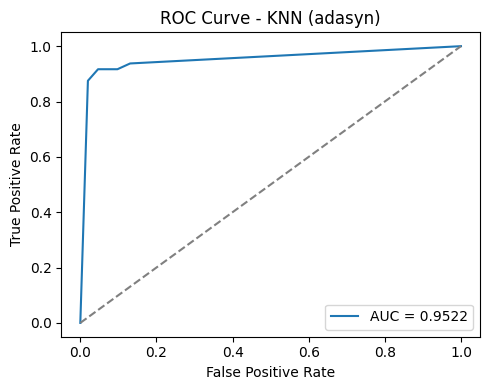

KNN [adasyn] -> Accuracy=0.9259  F1=0.9332  AUC=0.9521664818920916

Training SVM on adasyn-balanced data ...
Training time: 7.530 sec


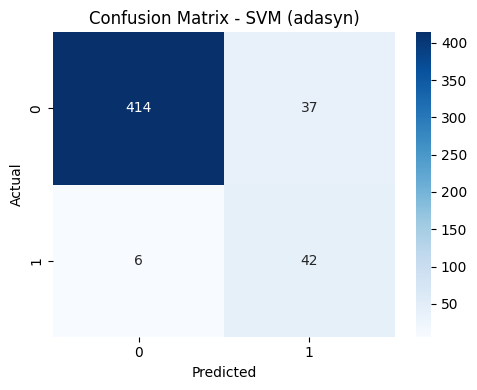

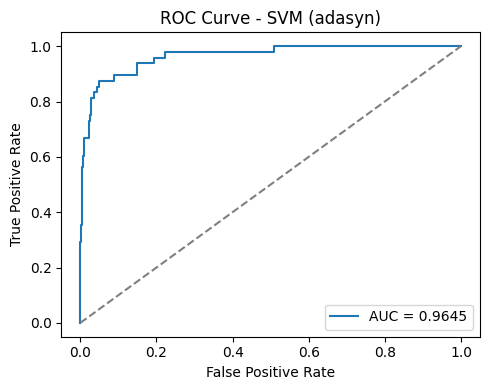

SVM [adasyn] -> Accuracy=0.9138  F1=0.9228  AUC=0.9644770879526977

Training NaiveBayes on adasyn-balanced data ...
Training time: 0.009 sec


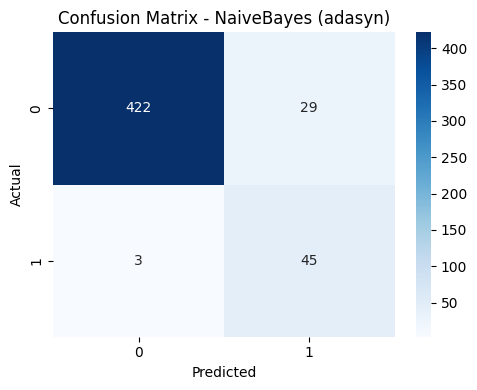

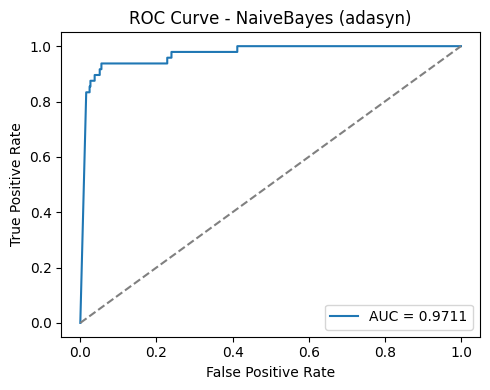

NaiveBayes [adasyn] -> Accuracy=0.9359  F1=0.9418  AUC=0.971128972653363


In [9]:
trained_balanced = {}

for bname, (X_bal, y_bal) in balanced_data.items():
    print(f"\n========== Balancing technique: {bname} ==========")
    for name, model_template in baseline_models.items():
        # fresh copy of the same model type
        model = type(model_template)(**model_template.get_params())
        print(f"\nTraining {name} on {bname}-balanced data ...")
        fitted, t = time_fit(model, X_bal, y_bal)
        print(f"Training time: {t:.3f} sec")
        evaluate_model(fitted, X_test, y_test, model_name=name, stage_tag=bname)
        trained_balanced[f"{bname}_{name}"] = fitted

### Baseline vs Balanced comparison table

In [10]:
results_df = pd.DataFrame(all_results)
pivot_f1 = results_df.pivot_table(index="model", columns="stage", values="f1_weighted")
pivot_recall1 = results_df.pivot_table(index="model", columns="stage", values="recall_class1")

print("F1-score by model and stage:")
display(pivot_f1)

print("\nFraud-class (1) recall by model and stage:")
display(pivot_recall1)

F1-score by model and stage:


stage,adasyn,baseline,smote,smote_tomek
model,,,,
DecisionTree,0.946059,0.962760,0.966956,0.966956
KNN,0.933221,0.983487,0.954905,0.954905
LogisticRegression,0.886946,0.983487,0.976579,0.976579
NaiveBayes,0.941753,0.954252,0.958064,0.958064
RandomForest,0.979569,0.983487,0.983487,0.981518
SVM,0.922811,0.983310,0.983815,0.981879



Fraud-class (1) recall by model and stage:


stage,adasyn,baseline,smote,smote_tomek
model,,,,
DecisionTree,0.895833,0.854167,0.895833,0.895833
KNN,0.916667,0.854167,0.916667,0.916667
LogisticRegression,0.937500,0.854167,0.937500,0.937500
NaiveBayes,0.937500,0.875000,0.895833,0.895833
RandomForest,0.854167,0.854167,0.854167,0.854167
SVM,0.875000,0.833333,0.895833,0.895833


## Part 4 — Hyperparameter Optimization with PSO
We tune **RandomForest** and **LogisticRegression** using Particle Swarm
Optimization. Fitness is evaluated on the **held-out Validation set** (the
10% split from Part 1) — never the test set — so tuning stays honest and
the final test-set evaluation stays a fair, unseen comparison.

Edit `BEST_BALANCE_TECHNIQUE` below once you've looked at Part 3's results
(pick whichever balancing technique scored best).

In [11]:
BEST_BALANCE_TECHNIQUE = "smote"   # change to "smote_tomek" or "adasyn" if that one won in Part 3

X_bal, y_bal = balanced_data[BEST_BALANCE_TECHNIQUE]
# Validation set for PSO fitness = the held-out 10% validation split from Part 1
X_tr, y_tr = X_bal, y_bal

### PSO for Random Forest (n_estimators, max_depth, min_samples_split)

In [ ]:
def rf_fitness(particles):
    losses = []
    for p in particles:
        n_estimators = int(np.clip(p[0], 50, 300))
        max_depth = int(np.clip(p[1], 3, 30))
        min_samples_split = int(np.clip(p[2], 2, 20))
        model = RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        losses.append(1 - f1_score(y_val, preds, average="weighted"))
    return np.array(losses)

rf_bounds = (np.array([50, 3, 2]), np.array([300, 30, 20]))
rf_optimizer = ps.single.GlobalBestPSO(
    n_particles=10, dimensions=3,
    options={"c1": 0.5, "c2": 0.3, "w": 0.9}, bounds=rf_bounds,
)
rf_best_cost, rf_best_pos = rf_optimizer.optimize(rf_fitness, iters=15)

rf_best_params = {
    "n_estimators": int(np.clip(rf_best_pos[0], 50, 300)),
    "max_depth": int(np.clip(rf_best_pos[1], 3, 30)),
    "min_samples_split": int(np.clip(rf_best_pos[2], 2, 20)),
}
print("Best RandomForest params found by PSO:", rf_best_params)

final_rf = RandomForestClassifier(**rf_best_params, random_state=RANDOM_STATE, n_jobs=-1)
final_rf, rf_train_time = time_fit(final_rf, X_bal, y_bal)
evaluate_model(final_rf, X_test, y_test, model_name="RandomForest", stage_tag="pso")

2026-08-13 06:43:05,716 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:  87%|████████▋ |13/15, best_cost=0.0101

### PSO for Logistic Regression (C)

2026-08-13 06:57:55,267 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|15/15, best_cost=0.0216
2026-08-13 06:58:06,600 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.021592128454359982, best pos: [39.76342131]


Best LogisticRegression params found by PSO: {'C': 39.76342131215036}


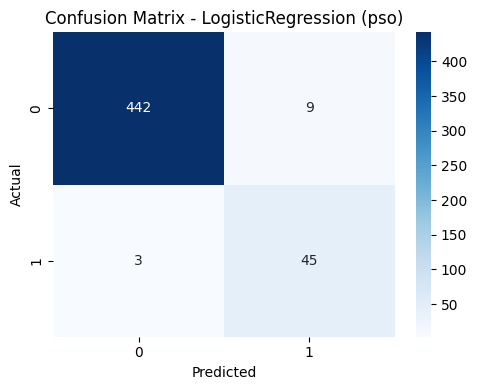

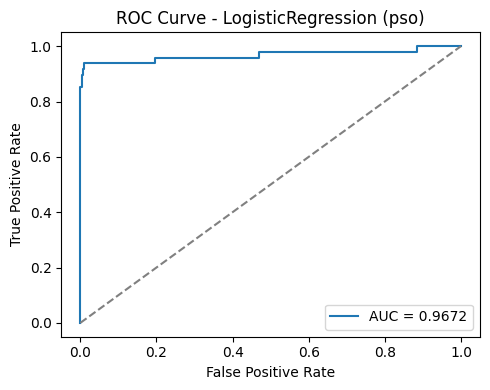

LogisticRegression [pso] -> Accuracy=0.9760  F1=0.9766  AUC=0.9672025129342202


{'stage': 'pso',
 'model': 'LogisticRegression',
 'accuracy': 0.9759519038076152,
 'precision_weighted': 0.9778748508252461,
 'recall_weighted': 0.9759519038076152,
 'f1_weighted': 0.9765786825752346,
 'roc_auc': np.float64(0.9672025129342202),
 'predict_time_sec': 0.001999378204345703,
 'precision_class0': 0.9932584269662922,
 'recall_class0': 0.9800443458980045,
 'f1_class0': 0.9866071428571429,
 'precision_class1': 0.8333333333333334,
 'recall_class1': 0.9375,
 'f1_class1': 0.8823529411764706}

In [ ]:
def lr_fitness(particles):
    losses = []
    for p in particles:
        C = float(np.clip(p[0], 0.001, 100))
        model = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        losses.append(1 - f1_score(y_val, preds, average="weighted"))
    return np.array(losses)

lr_bounds = (np.array([0.001]), np.array([100]))
lr_optimizer = ps.single.GlobalBestPSO(
    n_particles=10, dimensions=1,
    options={"c1": 0.5, "c2": 0.3, "w": 0.9}, bounds=lr_bounds,
)
lr_best_cost, lr_best_pos = lr_optimizer.optimize(lr_fitness, iters=15)

lr_best_params = {"C": float(np.clip(lr_best_pos[0], 0.001, 100))}
print("Best LogisticRegression params found by PSO:", lr_best_params)

final_lr = LogisticRegression(**lr_best_params, max_iter=1000, random_state=RANDOM_STATE)
final_lr, lr_train_time = time_fit(final_lr, X_bal, y_bal)
evaluate_model(final_lr, X_test, y_test, model_name="LogisticRegression", stage_tag="pso")

## Part 5 — Final Comparison: Baseline → Balanced → PSO-Optimized

In [ ]:
results_df = pd.DataFrame(all_results)
results_df.to_csv("results/tables/all_results.csv", index=False)

pivot_f1 = results_df.pivot_table(index="model", columns="stage", values="f1_weighted")
stage_order = [s for s in ["baseline","smote","smote_tomek","adasyn","pso"] if s in pivot_f1.columns]
pivot_f1 = pivot_f1[stage_order]

print("F1-score progression across all stages:")
display(pivot_f1)

best_row = results_df.loc[results_df["f1_weighted"].idxmax()]
print(f"\nBest overall result: {best_row['model']} at stage '{best_row['stage']}' "
      f"-> F1={best_row['f1_weighted']:.4f}, AUC={best_row['roc_auc']}")

balance_stages = [s for s in ["smote","smote_tomek","adasyn"] if s in results_df["stage"].unique()]
if balance_stages:
    avg_by_stage = results_df[results_df["stage"].isin(balance_stages)].groupby("stage")["f1_weighted"].mean()
    print("\nAverage F1 by balancing technique:")
    print(avg_by_stage.sort_values(ascending=False))

F1-score progression across all stages:


stage,baseline,smote,smote_tomek,adasyn,pso
model,,,,,
DecisionTree,0.962760,0.966956,0.966956,0.946059,NaN
KNN,0.983487,0.954905,0.954905,0.933221,NaN
LogisticRegression,0.983487,0.976579,0.976579,0.886946,0.976579
NaiveBayes,0.954252,0.958064,0.958064,0.941753,NaN
RandomForest,0.983487,0.983487,0.981518,0.979569,0.979569
SVM,0.983310,0.983815,0.981879,0.922811,NaN



Best overall result: SVM at stage 'smote' -> F1=0.9838, AUC=0.9804138950480414

Average F1 by balancing technique:
stage
smote          0.970634
smote_tomek    0.969984
adasyn         0.935060
Name: f1_weighted, dtype: float64


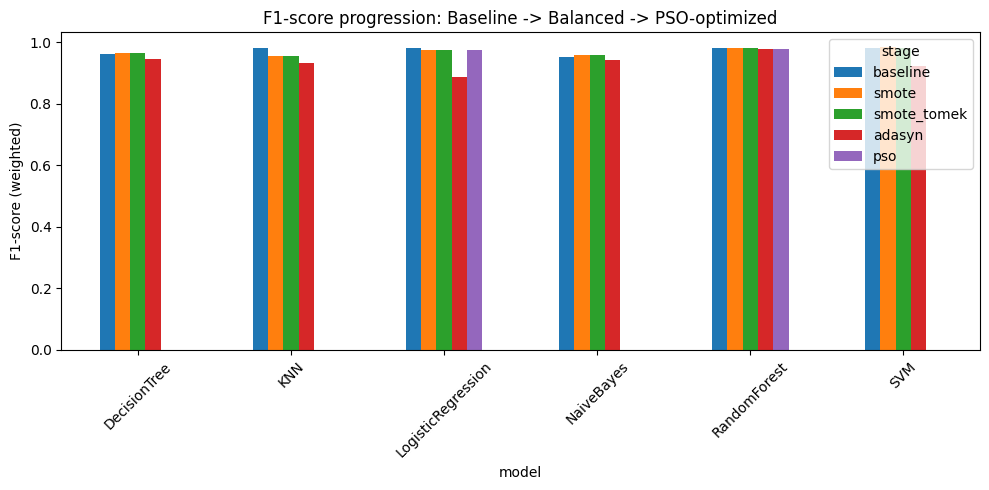

In [ ]:
# F1-score progression chart: Baseline -> Balanced -> PSO
ax = pivot_f1.plot(kind="bar", figsize=(10,5))
plt.ylabel("F1-score (weighted)")
plt.title("F1-score progression: Baseline -> Balanced -> PSO-optimized")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/tables/f1_progression_all_models.png", dpi=150)
plt.show()

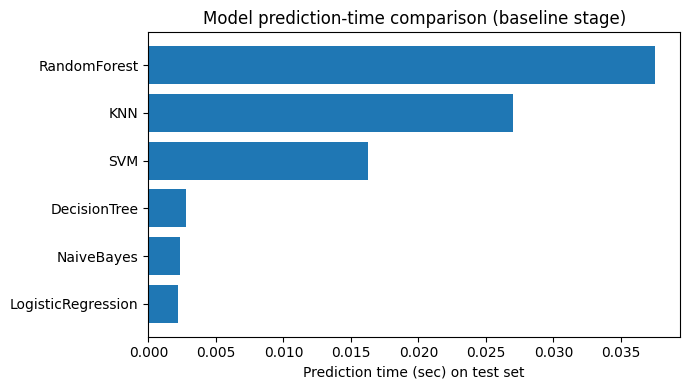

In [ ]:
# Prediction-time comparison (complexity analysis) - baseline stage
baseline_time_df = results_df[results_df["stage"]=="baseline"].sort_values("predict_time_sec")
plt.figure(figsize=(7,4))
plt.barh(baseline_time_df["model"], baseline_time_df["predict_time_sec"])
plt.xlabel("Prediction time (sec) on test set")
plt.title("Model prediction-time comparison (baseline stage)")
plt.tight_layout()
plt.savefig("results/tables/prediction_time_comparison.png", dpi=150)
plt.show()

## Part 6 (Bonus, optional) — Novel / Improved Methodology
Example: feature selection + PSO-tuned RandomForest using only the most
important features (from `final_rf.feature_importances_`). Edit / extend
this cell to try your own idea (ensemble, stacking, hybrid sampling, etc.)

Top 15 features by importance: ['V14', 'V10', 'V12', 'V4', 'V17', 'V16', 'V3', 'V11', 'V2', 'V7', 'V9', 'V18', 'V8', 'V21', 'V19']


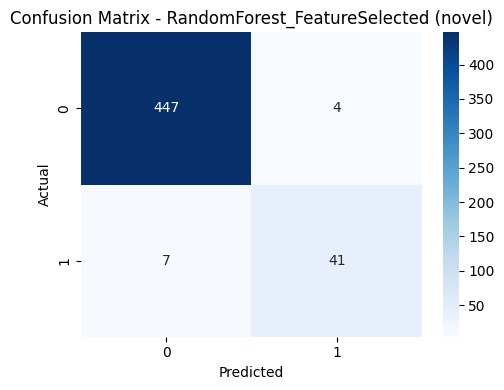

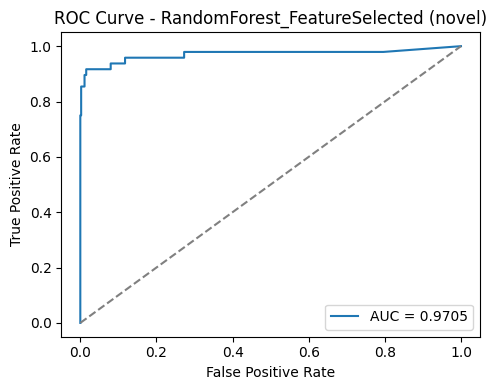

RandomForest_FeatureSelected [novel] -> Accuracy=0.9780  F1=0.9776  AUC=0.9704822616407982


{'stage': 'novel',
 'model': 'RandomForest_FeatureSelected',
 'accuracy': 0.9779559118236473,
 'precision_weighted': 0.9775142060920666,
 'recall_weighted': 0.9779559118236473,
 'f1_weighted': 0.9776368991770745,
 'roc_auc': np.float64(0.9704822616407982),
 'predict_time_sec': 0.03567028045654297,
 'precision_class0': 0.9845814977973568,
 'recall_class0': 0.991130820399113,
 'f1_class0': 0.9878453038674033,
 'precision_class1': 0.9111111111111111,
 'recall_class1': 0.8541666666666666,
 'f1_class1': 0.8817204301075269}

In [ ]:
importances = pd.Series(final_rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15).index.tolist()
print("Top 15 features by importance:", top_features)

X_train_fs = X_bal[top_features]
X_test_fs = X_test[top_features]

novel_model = RandomForestClassifier(**rf_best_params, random_state=RANDOM_STATE, n_jobs=-1)
novel_model, novel_train_time = time_fit(novel_model, X_train_fs, y_bal)
evaluate_model(novel_model, X_test_fs, y_test, model_name="RandomForest_FeatureSelected", stage_tag="novel")

## Save final results table (download this and use it in your report)

In [ ]:
results_df = pd.DataFrame(all_results)
results_df.to_csv("results/tables/all_results.csv", index=False)
results_df

,stage,model,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc,predict_time_sec,precision_class0,recall_class0,f1_class0,precision_class1,recall_class1,f1_class1
0,baseline,LogisticRegression,0.983968,0.983866,0.983968,0.983487,0.984248,0.002165,0.984683,0.997783,0.991189,0.976190,0.854167,0.911111
1,baseline,DecisionTree,0.961924,0.964035,0.961924,0.962760,0.913780,0.002792,0.984305,0.973392,0.978818,0.773585,0.854167,0.811881
2,baseline,RandomForest,0.983968,0.983866,0.983968,0.983487,0.976095,0.037498,0.984683,0.997783,0.991189,0.976190,0.854167,0.911111
3,baseline,KNN,0.983968,0.983866,0.983968,0.983487,0.944452,0.026985,0.984683,0.997783,0.991189,0.976190,0.854167,0.911111
4,baseline,SVM,0.983968,0.984247,0.983968,0.983310,0.967156,0.016233,0.982571,1.000000,0.991209,1.000000,0.833333,0.909091
5,baseline,NaiveBayes,0.951904,0.958790,0.951904,0.954252,0.962352,0.002312,0.986333,0.960089,0.973034,0.700000,0.875000,0.777778
6,smote,LogisticRegression,0.975952,0.977875,0.975952,0.976579,0.966694,0.002051,0.993258,0.980044,0.986607,0.833333,0.937500,0.882353
7,smote,DecisionTree,0.965932,0.968835,0.965932,0.966956,0.934613,0.002022,0.988739,0.973392,0.981006,0.781818,0.895833,0.834951
8,smote,RandomForest,0.983968,0.983866,0.983968,0.983487,0.976857,0.034931,0.984683,0.997783,0.991189,0.976190,0.854167,0.911111
9,smote,KNN,0.951904,0.961629,0.951904,0.954905,0.959812,0.086259,0.990805,0.955654,0.972912,0.687500,0.916667,0.785714


In [ ]:
from google.colab import files
files.download("results/tables/all_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>